2021-11-30 ~ 2023-12-01 까지 2년치 매일 30건씩

주차로 묶어서 시각화

# Figure 1(Difficulty)

In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_1): ")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting

import lib.annotation.tools.Result_Prep as rp

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/annotate_difficulty/{visualization_target}'
data_dir = f"{viz_dir}/data/csv"
option_dict = load_json(f"{viz_dir}/ver33330000/option.json")
output_dir = create_dir('./fig/')
date_range = 'Weekly'


# std_date = Date_Setting[option_dict['year_range']]['std_date']

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/hdd/mghan/so_difficulty_measure/result/annotate_difficulty/run_id_3/ver33330000/option.json'

In [4]:
path = f"{viz_dir}/{option_dict['operation_option']['llm_model']}"
file_list = os.listdir(path)

In [5]:
ver_list = sorted([y for y in [x for x in file_list if x.isdigit()] if (int(y)>=33330000) & (int(y)<33340000)])


In [6]:
ver_list

['33330001',
 '33330002',
 '33330005',
 '33330007',
 '33330010',
 '33330011',
 '33330014',
 '33330015',
 '33330018',
 '33330020',
 '33330022',
 '33330024',
 '33330027',
 '33330028',
 '33330031',
 '33330033',
 '33330036',
 '33330037',
 '33330040',
 '33330041',
 '33330044',
 '33330046',
 '33330049',
 '33330050',
 '33330053',
 '33330054',
 '33330057',
 '33330059',
 '33330062',
 '33330063',
 '33330066',
 '33330067',
 '33330070',
 '33330072',
 '33330075',
 '33330076',
 '33330079',
 '33330080',
 '33330083',
 '33330085',
 '33330088',
 '33330089',
 '33330092',
 '33330094',
 '33330096',
 '33330098',
 '33330101',
 '33330102',
 '33330105',
 '33330107',
 '33330110',
 '33330111',
 '33330114',
 '33330115',
 '33330118',
 '33330120',
 '33330123',
 '33330124',
 '33330127',
 '33330128',
 '33330131',
 '33330133',
 '33330136',
 '33330137',
 '33330140',
 '33330141',
 '33330144',
 '33330146',
 '33330149',
 '33330150',
 '33330153',
 '33330155',
 '33330157',
 '33330159',
 '33330162',
 '33330163',
 '33330166',

In [7]:
r_p = rp.Result_Prep()

In [8]:
tot_calc = pd.DataFrame()
for listid in ver_list:
    df = r_p.make_one_file(listid, path)
    if isinstance(df, pd.core.frame.DataFrame):
        df = r_p.pp_df(df, 5)
        if df.shape[0]>0 :
            df = r_p.calc_rate_byweek(df)
            tot_calc = pd.concat([tot_calc, df], axis = 0)

    

In [9]:
def draw_complexity_regression(ax, x, y, st_chow_1year,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1

    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # scatter
    ax.scatter(x, y, color='darkgray', alpha=0.7, s=10, marker='x')

    # Full model
    ax.plot(x, st_chow_1year.y_predict,
            linestyle="--", color="black",
            linewidth=1.5, label='Overall fit')

    # Before ChatGPT
    ax.plot(x1, st_chow_1year.y1_predict,
            linewidth=1.5, label='Before ChatGPT')

    ax.fill_between(
        x1,
        st_chow_1year.y1_predict - st_chow_1year.y1_conf_interval,
        st_chow_1year.y1_predict + st_chow_1year.y1_conf_interval,
        alpha=0.15
    )

    # After ChatGPT
    ax.plot(x2, st_chow_1year.y2_predict,
            linewidth=1.5, label='After ChatGPT')

    ax.fill_between(
        x2,
        st_chow_1year.y2_predict - st_chow_1year.y2_conf_interval,
        st_chow_1year.y2_predict + st_chow_1year.y2_conf_interval,
        alpha=0.15
    )

    # vertical line
    ax.axvline(x=0, color='#CC3333', linestyle='--', linewidth=1.2, zorder=5)

    # p-value text
    p_txt = '$p < 0.001$' if p_value_1 < 0.001 else f'$p = {p_value_1:.3f}$'
    p_color = '#CC3333' if p_value_1 < 0.05 else 'gray'

    # title
    ax.text(
        0.5, 1.08,
        f'Changes in {title}',
        transform=ax.transAxes,
        fontsize=font_setting.font_setting['title'],
        ha='center',
        va='bottom'
    )

    # p-value
    ax.text(
        0.5, 1.02,
        p_txt,
        ha='center',
        fontsize=font_setting.font_setting['p-value'],
        color=p_color,
        transform=ax.transAxes
    )

    # panel label
    if panel_label:
        ax.text(
            -0.08, 1.08,
            panel_label,
            transform=ax.transAxes,
            fontsize=font_setting.font_setting['panel'],
            fontweight='bold',
            va='bottom',
            ha='left'
        )

    # axis labels
    ax.set_xlabel("Week relative to ChatGPT release", fontsize=font_setting.font_setting['label'])
    ax.set_ylabel("Percentage(%)", fontsize=font_setting.font_setting['label'])

    # ticks
    ax.tick_params(axis='both', labelsize=font_setting.font_setting['tick'])

    # spine
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # grid
    ax.yaxis.grid(True, linestyle=':', linewidth=0.5,
                  color='gray', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

    # legend
    ax.legend(fontsize=font_setting.font_setting['legend'], frameon=False)

In [10]:
tot_calc[tot_calc['rel_week'] > 0]

,rel_week,o_result,r_cnt,tot_cnt,rate
0,1.0,0,49,111,44.144144
1,1.0,1,52,111,46.846847
2,1.0,2,10,111,9.009009
0,2.0,0,50,148,33.783784
1,2.0,1,72,148,48.648649
...,...,...,...,...,...
1,150.0,1,3,8,37.500000
2,150.0,2,4,8,50.000000
0,153.0,1,4,4,100.000000
0,155.0,0,1,2,50.000000


86
24
94
24
91
24


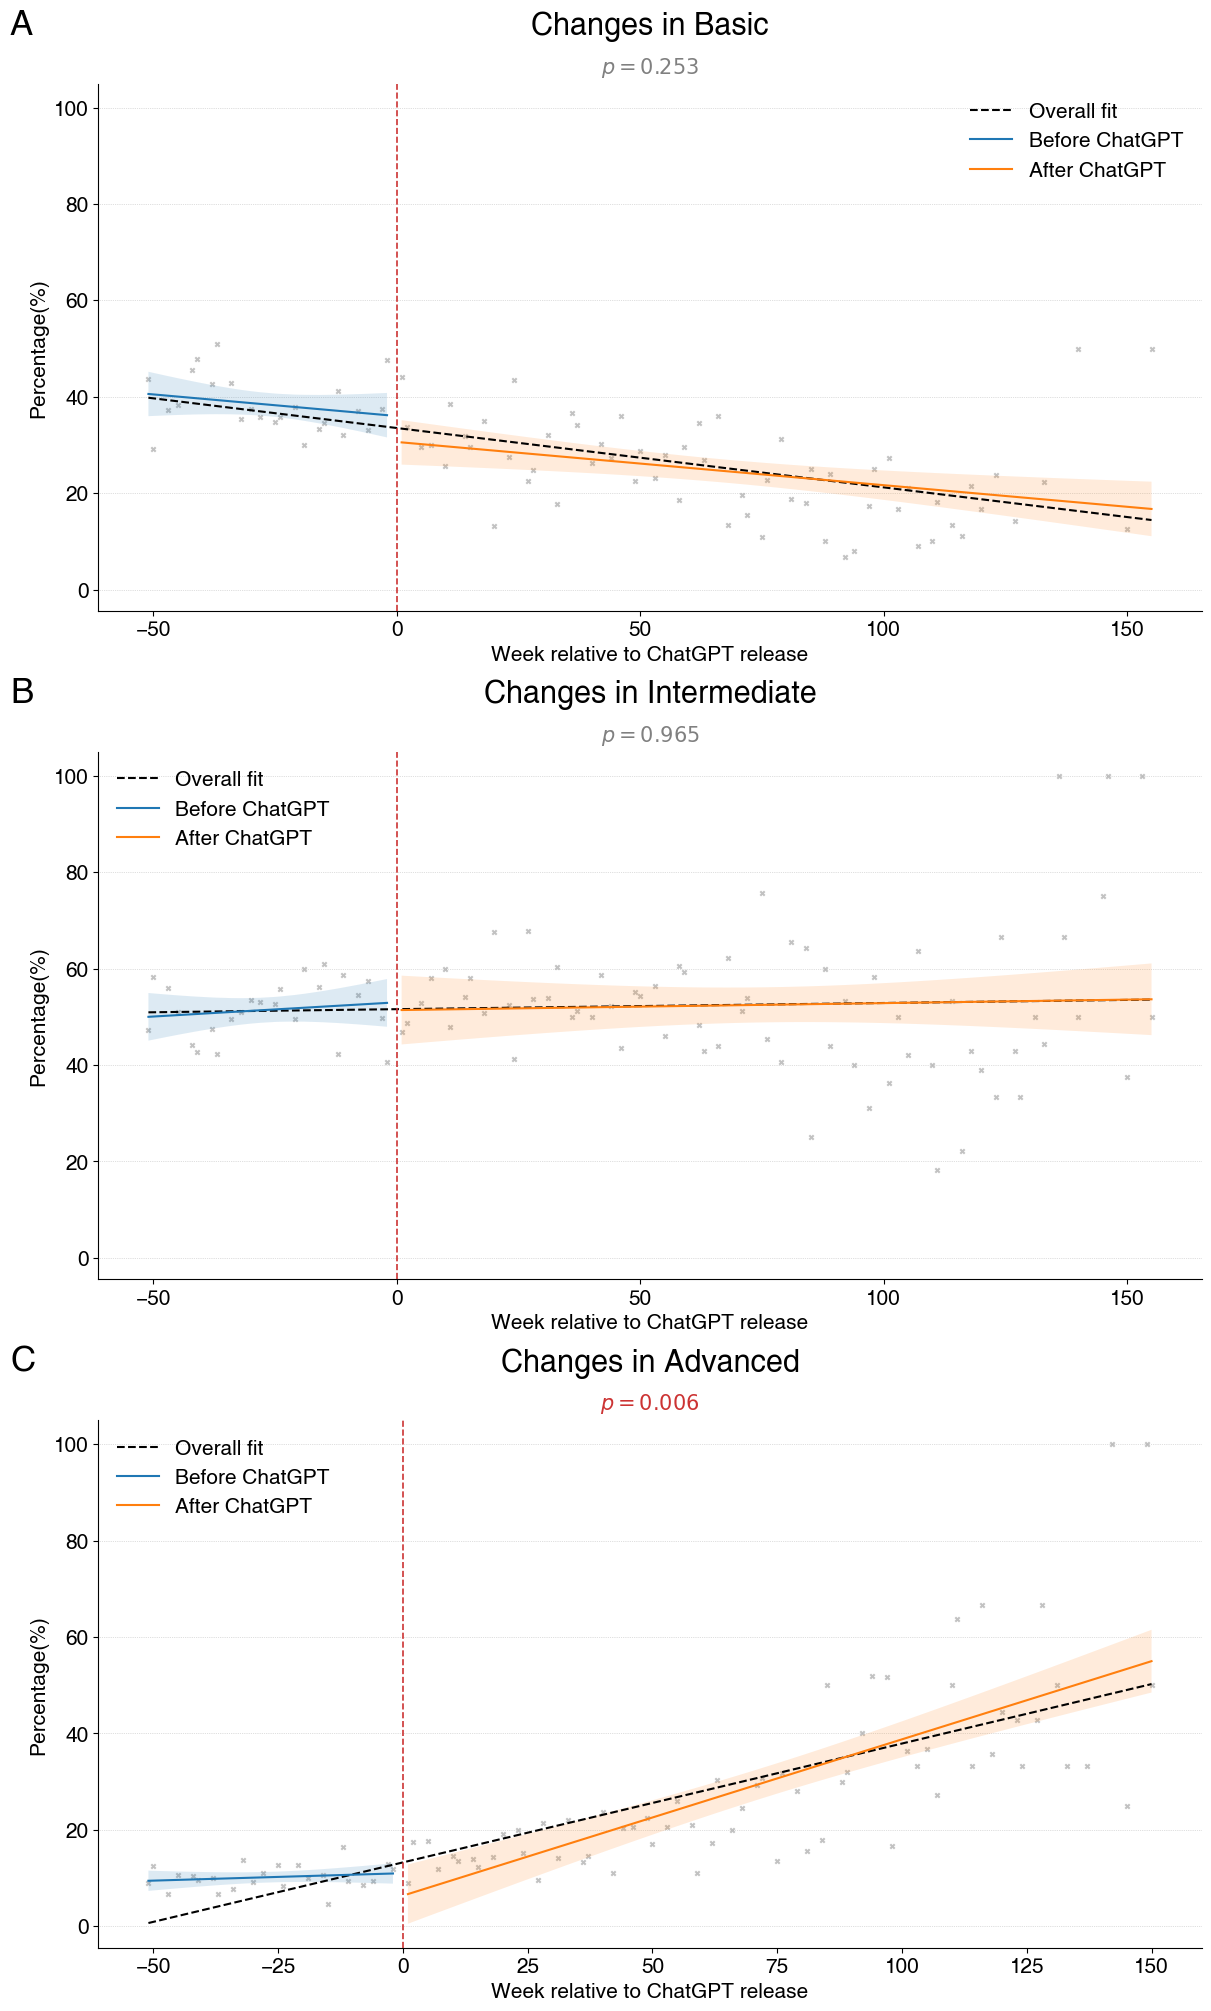

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(12,20), constrained_layout=True, sharey=True)
label_dict = {'A' : 'Basic', 'B' : 'Intermediate', 'C':'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = tot_calc[tot_calc['o_result'] == str(i)].sort_values(by = ['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, chk_cnt[chk_cnt['rel_week'] ==1].index.values[0])
    F_stat, p_value = st_chow.chow_test()
    print(len(y))
    print(len(st_chow.y1_predict))
    draw_complexity_regression(
        ax[i],
        x,
        y,
        st_chow,
        F_stat,
        p_value,
        title=f"{title}",
        panel_label=f"{label}"
    )



plt.savefig(
    f"{output_dir}/{visualization_target}.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()